# Process Zillow Home Value Index

Load and transform the Zillow home value index. 

Uses geopy library. Run `%pip install geopy` in the ipynb

- Append latitute, longitude per msa

## Dependencies

In [153]:
# %pip install geopy
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest

In [107]:
class ZillowData():
    DTYPES = {
        'RegionID': 'int64',
        'SizeRank': 'int64',
        'RegionName': 'string',
        'RegionType': 'string',
        'StateName': 'string'
    }
    
    META_DATA_COLS = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
    
    def __init__(self, raw_data_path):
        self.df = pd.read_csv(raw_data_path, dtype=self.DTYPES)
        
    def region_time_series(self, region):
        """Returns DataFrame with one colums of time series data

        onvert the 

        """

        regional = self.df[self.df['RegionName']==region]
        regional_data = regional.loc[:, self.date_cols()].T
        regional_data.columns = [region]
        regional_data.index = pd.to_datetime(regional_data.index)
        return regional_data

    def date_cols(self):
        dates = [col for col in self.df.columns if col not in self.META_DATA_COLS]
        dates = sorted(dates, key=pd.to_datetime)
        return list(dates)
    


## Load raw data from csv

In [108]:
zhvi_raw = Path('../data/raw/ZHVI_2026_01_08_raw.csv')
assert zhvi_raw.exists()

In [109]:
zhvi = ZillowData(zhvi_raw)
zhvi.df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30
0,102001,0,United States,country,<NA>,121365.463017,121578.983773,121843.780950,122411.718918,123065.347427,...,360639.085047,360365.882152,359841.918311,359161.728607,358549.348441,358126.082695,357900.244881,358139.907469,358570.726255,359241.248814
1,394913,1,"New York, NY",msa,NY,217048.914950,217971.250375,218902.128288,220788.447146,222741.795647,...,683063.089259,684751.535661,687173.496480,688933.036680,690400.936533,691567.341599,692353.209509,693746.473781,696069.806090,699394.634661
2,753899,2,"Los Angeles, CA",msa,CA,218336.580065,219149.069165,220231.296899,222384.566542,224739.568479,...,948074.673902,943052.689223,938798.754881,934095.397500,929804.957480,927250.711189,926195.042763,927236.358557,929617.284624,932886.242451
3,394463,3,"Chicago, IL",msa,IL,151721.660042,151862.110101,152129.599712,152795.047391,153595.500906,...,326483.919256,327320.371223,327914.592965,328201.936285,328558.836926,329388.734181,330373.317156,331691.388829,332981.532008,334511.786740
4,394514,4,"Dallas, TX",msa,TX,126887.587653,126944.103828,127009.074957,127177.798153,127400.255068,...,372494.812737,371001.024231,368886.369472,366484.365155,364134.164489,362129.302053,360775.171809,360131.881806,359785.324832,359523.202747


In [110]:
"""check the data types"""
df = zhvi.df

assert df.dtypes['RegionID'] == 'int64'
assert df.dtypes['SizeRank'] == 'int64'
assert df.dtypes['RegionName'] == 'string'
assert df.dtypes['RegionType'] == 'string'
assert df.dtypes['StateName'] == 'string'
assert df.dtypes['2025-11-30'] == 'float64'
assert df.dtypes['2000-01-31'] == 'float64'

In [111]:

latest_month = df.columns[-1]
print(f"Latest data is from: {latest_month}")

Latest data is from: 2025-11-30


## National Data

In [112]:
national = zhvi.region_time_series("United States")
assert national.columns == ["United States"], "column labeled for region"
assert len(national) == 311, "Data through 2025-11-30"
assert isinstance(national.index, pd.DatetimeIndex)
assert national.loc['2000-01-31', 'United States'] == pytest.approx(121365.46, abs=1e-2)
assert national.loc['2025-11-30', 'United States'] == pytest.approx(359241.25, abs=1e-2)

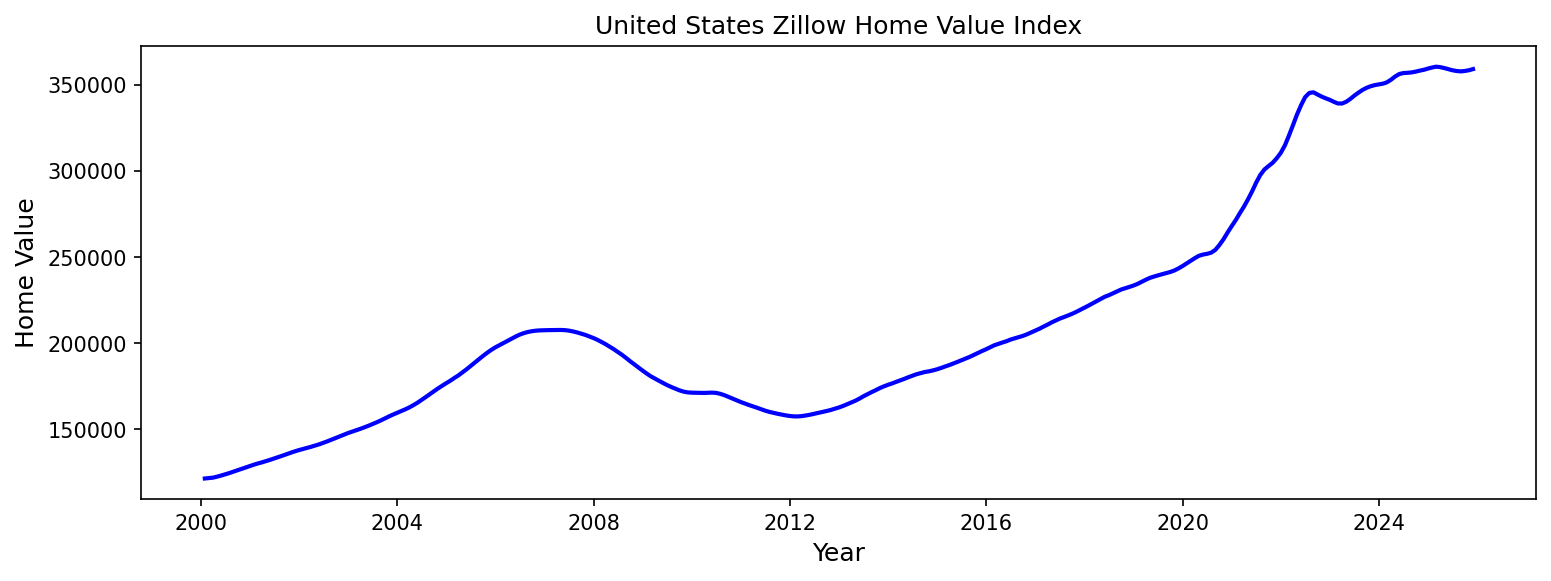

In [156]:
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(national.index, national['United States'], color='blue', linewidth=2)
plt.title("United States Zillow Home Value Index")
plt.ylabel("Home Value", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.show()

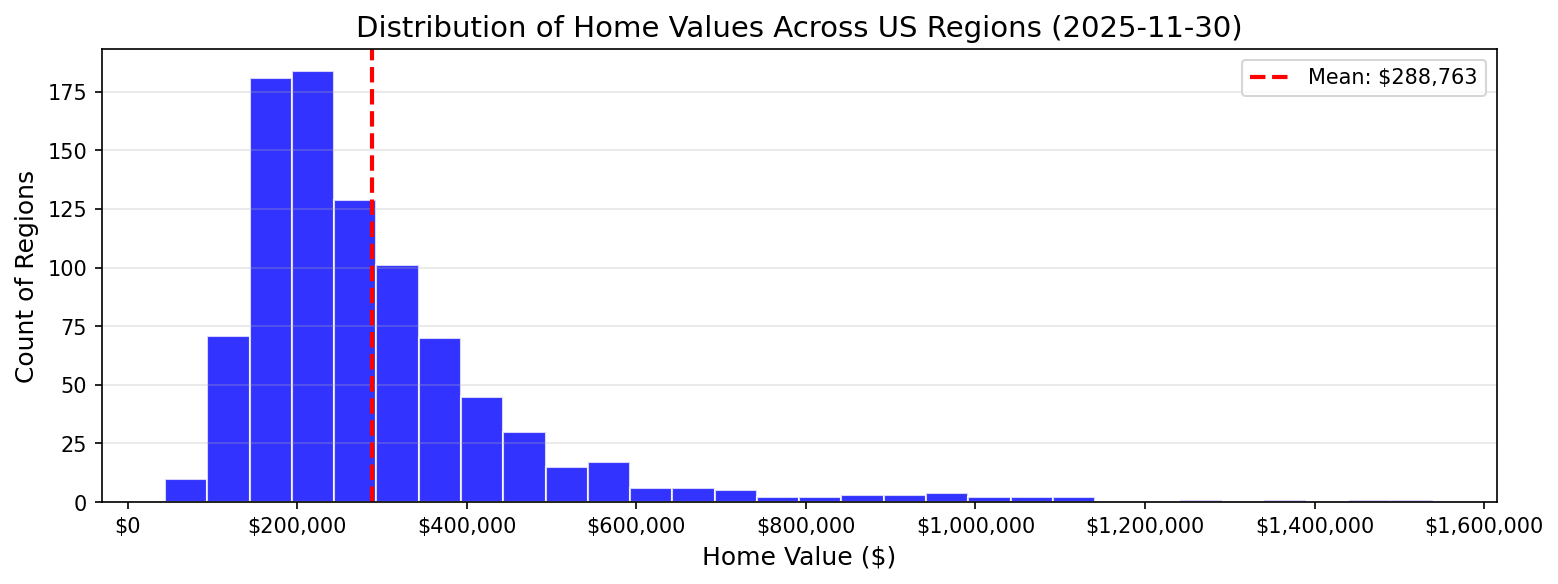

In [157]:
regions = df[df["RegionName"] != "United States"]
current = regions.loc[:, latest_month].dropna()

mean_val = current.mean()

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)

ax.hist(current, bins=30, color="blue", edgecolor='white', alpha=0.8)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.xaxis.set_major_formatter(formatter)

ax.set_title(f'Distribution of Home Values Across US Regions ({latest_month})', fontsize=14)
ax.set_ylabel("Count of Regions", fontsize=12)
ax.set_xlabel('Home Value ($)', fontsize=12)
ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: ${mean_val:,.0f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

## Geocoding

In [159]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.geocoder import Geocoder

In [160]:
cache_file = Path('../data/processed/geolocations.csv')
geocoder = Geocoder(cache_file)

EmptyDataError: No columns to parse from file

In [158]:
location = geocoder.geocode("Chicago, IL")

NameError: name 'geocoder' is not defined